In [24]:
import pandas as pd
import os.path
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pandas import json_normalize
from scipy.optimize import curve_fit

sns.set_theme()

import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

# Generate dataset

In [25]:
root_data = '../source_data/'

with open(root_data + "timeline/timeline.json", "r") as f:
    data = json.load(f)

# Flatten only the "instances" array
df = pd.json_normalize(
    data["instances"],
    sep="_"
)

df = df[[
    "_index",
    "uid",
    "instance_type",
    "instance_category",
    "instance_generation",
    "release_month",
    "release_year",
    "product_page",
    "announcement_url"
]]

df['date'] = pd.to_datetime(df['release_month'] + ' ' + df['release_year'].astype(str), format="%B %Y")

In [26]:
flavor_files = ['/instances/ec2-instances-gen-general.csv', 'instances/ec2-instances-gen-compute.csv', 'instances/ec2-instances-gen-memory.csv', 
                'instances/ec2-instances-gen-storage.csv', 'instances/ec2-instances-gen-accel.csv', 'instances/ec2-instances-gen-hpc.csv',
                'instances/ec2-instances-gen-previous.csv']
flavor_label = ['general', 'compute', 'memory', 'storage', 'accelerator', 'hpc', 'previous']  # distinct label for each file

df_list = []
for file, label in zip(flavor_files, flavor_label):
    temp = pd.read_csv(root_data + file)
    temp['category'] = label  # add label column
    df_list.append(temp)

flavors = pd.concat(df_list, ignore_index=True)
print(len(flavors))

1081


In [27]:
# Boolean mask for instance types not in flavors
mask = ~df['instance_type'].isin(flavors['Instance'])

# Highlight or filter them
df_not_in_flavors = df[mask]
df_not_in_flavors

,_index,uid,instance_type,instance_category,instance_generation,release_month,release_year,product_page,announcement_url,date
8,9,6fabd67a7645aa5b,cc1.4xlarge,Cluster Compute,Previous generation,July,2010,https://aws.amazon.com/ec2/previous-generation/,https://aws.amazon.com/about-aws/whats-new/201...,2010-07-01
10,11,2b69ab23d8a2d382,cg1.4xlarge,Cluster GPU,Previous generation,November,2010,https://aws.amazon.com/ec2/previous-generation/,https://aws.amazon.com/about-aws/whats-new/201...,2010-11-01
11,12,580ffe5a7c96457f,cc2.8xlarge,Cluster Compute,Previous generation,November,2011,https://aws.amazon.com/ec2/previous-generation/,https://aws.amazon.com/about-aws/whats-new/201...,2011-11-01
13,14,66cfb564aca0f5d6,hi1.4xlarge,High I/O,Previous generation,July,2012,https://aws.amazon.com/ec2/previous-generation/,https://aws.amazon.com/about-aws/whats-new/201...,2012-07-01
16,17,35cf0920239d9ff4,hs1.8xlarge,Storage Optimized,Previous generation,December,2012,https://aws.amazon.com/ec2/previous-generation/,https://aws.amazon.com/about-aws/whats-new/201...,2012-12-01
17,18,05ed3e0c1b386b0d,cr1.8xlarge,Memory Optimized,Previous generation,January,2013,https://aws.amazon.com/ec2/previous-generation/,https://aws.amazon.com/about-aws/whats-new/201...,2013-01-01
18,19,621c80075156ac27,g2.2xlarge,Accelerated Computing,Previous generation,November,2013,https://aws.amazon.com/ec2/previous-generation/,https://aws.amazon.com/about-aws/whats-new/201...,2013-11-01
47,48,b7dbd4041ea30d37,g2.8xlarge,Accelerated Computing,Previous generation,April,2015,https://aws.amazon.com/ec2/previous-generation/,https://aws.amazon.com/about-aws/whats-new/201...,2015-04-01
147,148,5520c3bd6d56dbb8,g3s.xlarge,Accelerated Computing,Previous generation,October,2018,https://aws.amazon.com/ec2/previous-generation/,https://aws.amazon.com/about-aws/whats-new/201...,2018-10-01


In [28]:
merged_df = df.merge(
    flavors,
    left_on='instance_type',
    right_on='Instance',
    how='inner'
)

print(len(merged_df), 'instances')
merged_df.to_csv('../dataset.csv')

1064 instances


# Explore

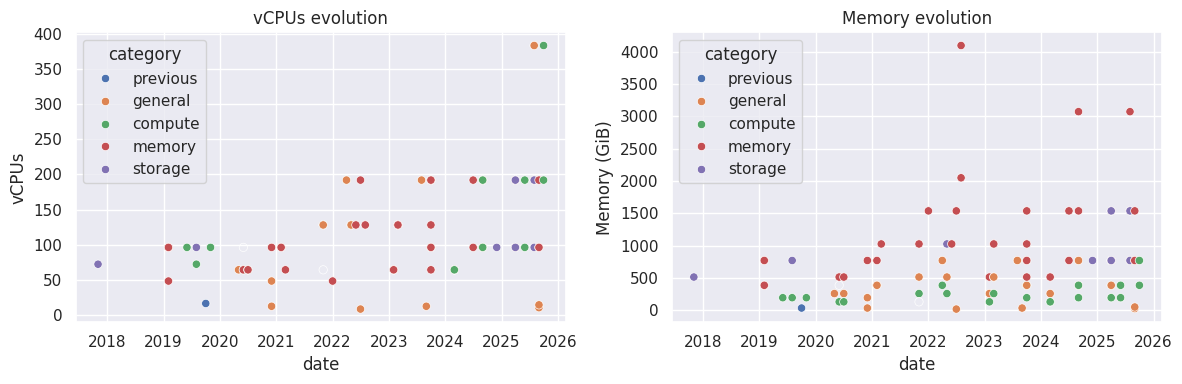

In [29]:
# Hardware evolution

hardware_df = merged_df[merged_df['instance_type'].str.contains('metal')]
hardware_df = hardware_df[hardware_df['Memory (GiB)'] < 5000]

fig, axes = plt.subplots(1, 2, figsize=(12,4), sharex=True)

# Left: vCPUs
sns.scatterplot(
    data=hardware_df,
    x='date',
    y='vCPUs',
    hue='category',
    hue_order=['previous', 'general', 'compute', 'memory', 'storage'],
    ax=axes[0]
)
axes[0].set_title("vCPUs evolution")

# Right: Memory
sns.scatterplot(
    data=hardware_df,
    x='date',
    y='Memory (GiB)',
    hue='category',
    hue_order=['previous', 'general', 'compute', 'memory', 'storage'],
    ax=axes[1]
)
axes[1].set_title("Memory evolution")

plt.tight_layout()
plt.show()

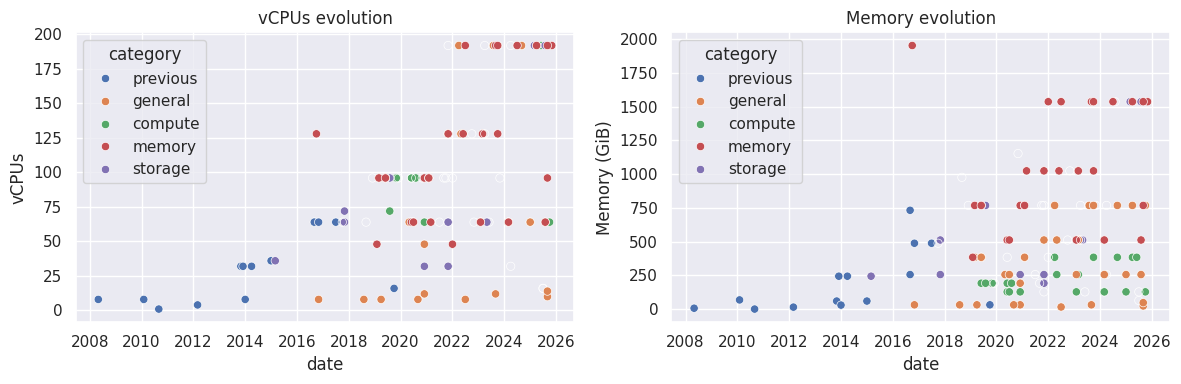

In [30]:
# Max size evolution

merged_df['product_id'] = merged_df['instance_type'].str.split('.').str[0]
flavor_max = merged_df.groupby('product_id')[['vCPUs', 'Memory (GiB)', 'category', 'date']].max()

# Remove outliers
flavor_max = flavor_max.loc[flavor_max['vCPUs'] < 200]
flavor_max = flavor_max.loc[flavor_max['Memory (GiB)'] < 2000]

fig, axes = plt.subplots(1, 2, figsize=(12,4), sharex=True)

# Left: vCPUs
sns.scatterplot(
    data=flavor_max,
    x='date',
    y='vCPUs',
    hue='category',
    hue_order=['previous', 'general', 'compute', 'memory', 'storage'],
    ax=axes[0]
)
axes[0].set_title("vCPUs evolution")

# Right: Memory
sns.scatterplot(
    data=flavor_max,
    x='date',
    y='Memory (GiB)',
    hue='category',
    hue_order=['previous', 'general', 'compute', 'memory', 'storage'],
    ax=axes[1]
)
axes[1].set_title("Memory evolution")

plt.tight_layout()
plt.show()

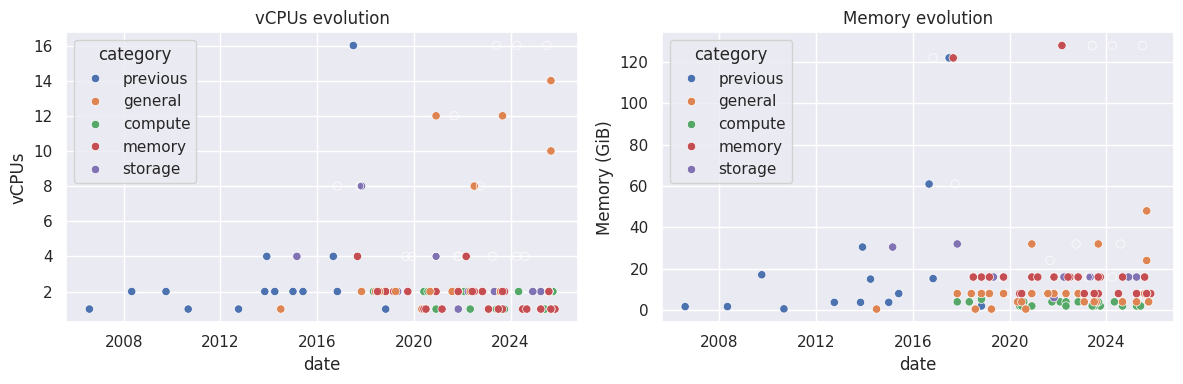

In [31]:
# MIn size evolution

merged_df['product_id'] = merged_df['instance_type'].str.split('.').str[0]
flavor_min = merged_df.groupby('product_id')[['vCPUs', 'Memory (GiB)', 'category', 'date']].min()

# Remove outliers
flavor_min = flavor_min.loc[flavor_min['vCPUs'] < 40]
flavor_min = flavor_min.loc[flavor_min['Memory (GiB)'] < 200]

fig, axes = plt.subplots(1, 2, figsize=(12,4), sharex=True)

# Left: vCPUs
sns.scatterplot(
    data=flavor_min,
    x='date',
    y='vCPUs',
    hue='category',
    hue_order=['previous', 'general', 'compute', 'memory', 'storage'],
    ax=axes[0]
)
axes[0].set_title("vCPUs evolution")

# Right: Memory
sns.scatterplot(
    data=flavor_min,
    x='date',
    y='Memory (GiB)',
    hue='category',
    hue_order=['previous', 'general', 'compute', 'memory', 'storage'],
    ax=axes[1]
)
axes[1].set_title("Memory evolution")

plt.tight_layout()
plt.show()

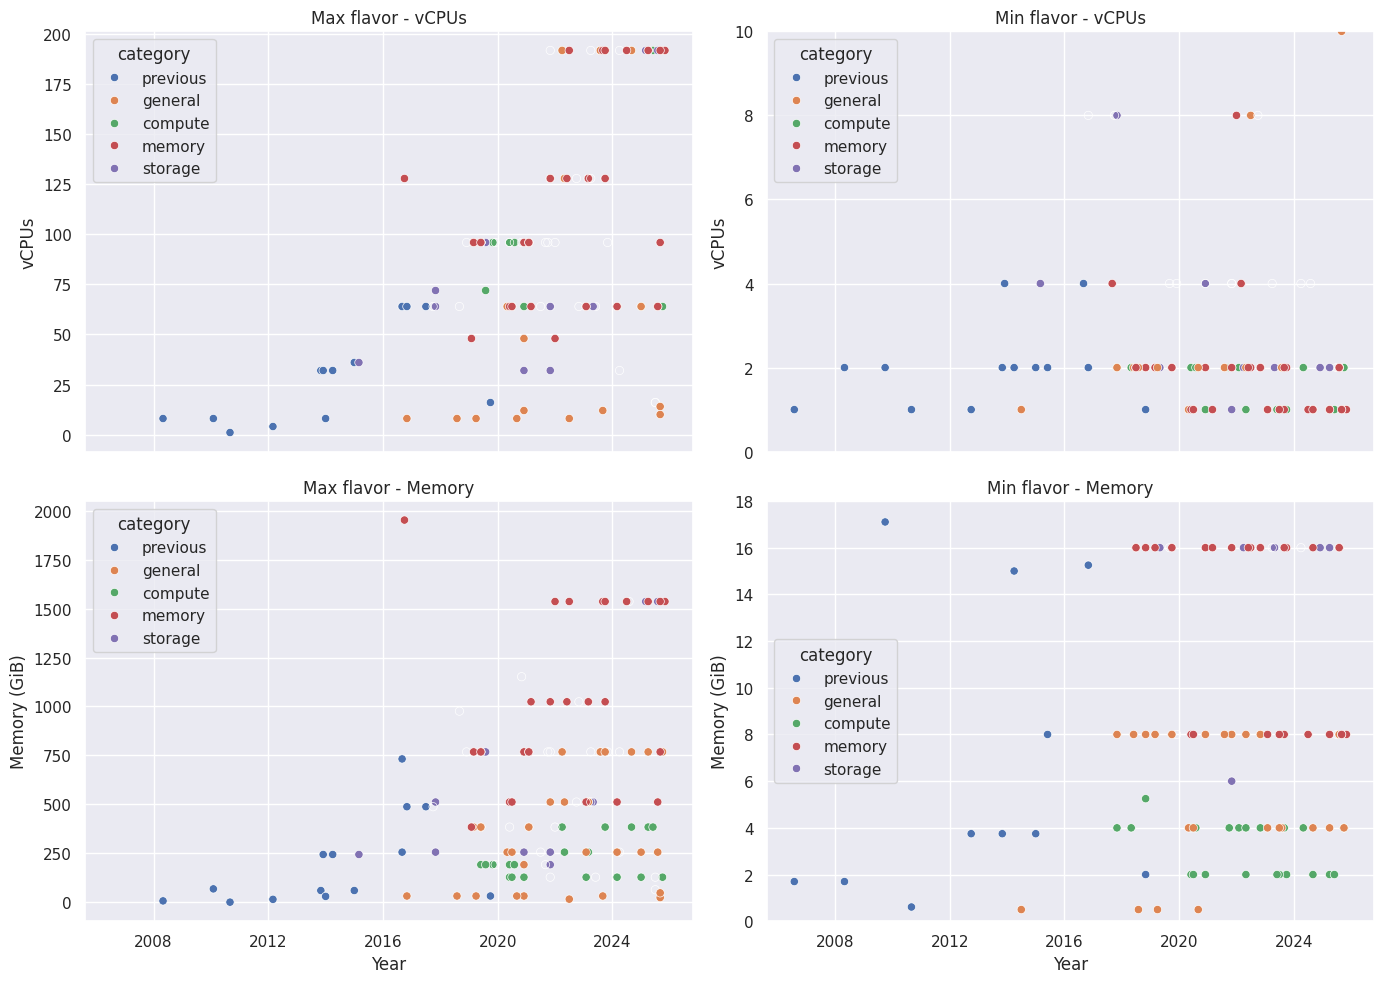

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Prepare data
merged_df['product_id'] = merged_df['instance_type'].str.split('.').str[0]

# Compute min and max per product
flavor_max = merged_df.groupby('product_id')[['vCPUs', 'Memory (GiB)', 'category', 'date']].max().reset_index()
flavor_min = merged_df.groupby('product_id')[['vCPUs', 'Memory (GiB)', 'category', 'date']].min().reset_index()

# Filter out outliers
flavor_max = flavor_max[(flavor_max['vCPUs'] < 200) & (flavor_max['Memory (GiB)'] < 2000)]
flavor_min = flavor_min[(flavor_min['vCPUs'] < 200) & (flavor_min['Memory (GiB)'] < 2000)]

fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True)

# Top row: vCPUs
sns.scatterplot(
    data=flavor_max, x='date', y='vCPUs', hue='category',
    hue_order=['previous', 'general', 'compute', 'memory', 'storage'],
    ax=axes[0,0]
)
axes[0,0].set_title("Max flavor - vCPUs")
axes[0,0].set_ylabel("vCPUs")

sns.scatterplot(
    data=flavor_min, x='date', y='vCPUs', hue='category',
    hue_order=['previous', 'general', 'compute', 'memory', 'storage'],
    ax=axes[0,1]
)
axes[0,1].set_title("Min flavor - vCPUs")
axes[0,1].set_ylabel("vCPUs")
axes[0,1].set(ylim=(0,10))

# Bottom row: Memory
sns.scatterplot(
    data=flavor_max, x='date', y='Memory (GiB)', hue='category',
    hue_order=['previous', 'general', 'compute', 'memory', 'storage'],
    ax=axes[1,0]
)
axes[1,0].set_title("Max flavor - Memory")
axes[1,0].set_ylabel("Memory (GiB)")
axes[1,0].set(xlabel='Year')

sns.scatterplot(
    data=flavor_min, x='date', y='Memory (GiB)', hue='category',
    hue_order=['previous', 'general', 'compute', 'memory', 'storage'],
    ax=axes[1,1]
)
axes[1,1].set_title("Min flavor - Memory")
axes[1,1].set_ylabel("Memory (GiB)")
axes[1,1].set(ylim=(0,18), xlabel='Year')

plt.tight_layout()
plt.gcf().savefig('figures/flavors-aws.pdf', bbox_inches='tight')

/tmp/ipykernel_25103/1441981615.py:29: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels([(flavor_min_small['date'].min() + pd.to_timedelta(t*365, unit='D')).strftime('%Y') for t in xticks])
/tmp/ipykernel_25103/1441981615.py:62: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(dates)


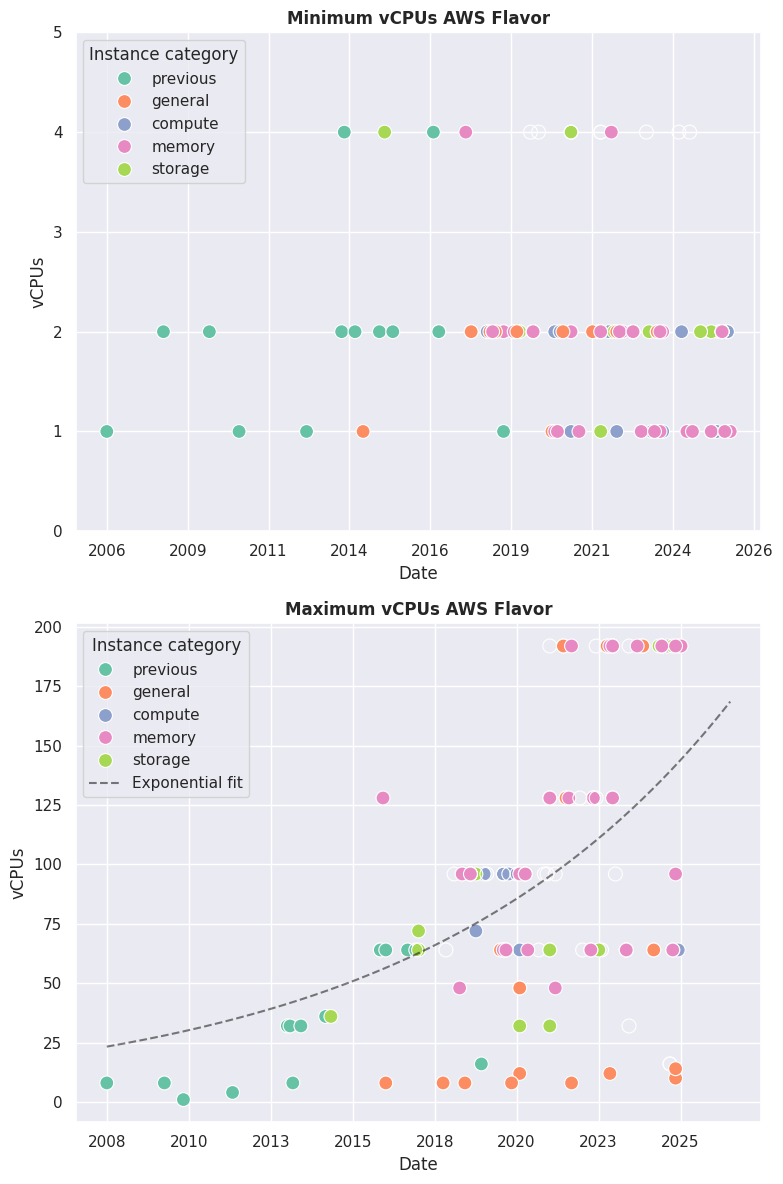

In [39]:
fig, axes = plt.subplots(2, 1, figsize=(8, 12))  # 1 row, 2 columns

# --- MIN flavor (left) ---
flavor_min_small = flavor_min.loc[flavor_min['vCPUs'] <= 6]
x_years = (flavor_min_small['date'] - flavor_min_small['date'].min()).dt.days / 365
y = flavor_min_small['vCPUs']

sns.scatterplot(
    x=x_years,
    y=y,
    hue=flavor_min_small['category'],
    hue_order=['previous', 'general', 'compute', 'memory', 'storage'],
    palette='Set2',
    s=100,
    ax=axes[0]
)

def linear_fixed_intercept(x, slope):
    return 1 + slope * x

popt, _ = curve_fit(linear_fixed_intercept, x_years, y, p0=[1])
slope = popt[0]
x_fit = np.linspace(0, x_years.max(), 200)
y_fit = linear_fixed_intercept(x_fit, slope)
# axes[0].plot(x_fit, y_fit, 'k--', alpha=0.7, label='Linear fit')
# axes[0].legend()

xticks = axes[0].get_xticks()
axes[0].set_xticklabels([(flavor_min_small['date'].min() + pd.to_timedelta(t*365, unit='D')).strftime('%Y') for t in xticks])
axes[0].set_xlabel("Date")
axes[0].set_ylabel("vCPUs")
axes[0].set_title("Minimum vCPUs AWS Flavor", fontsize=12, fontweight='bold')
axes[0].legend(title="Instance category")
axes[0].set_ylim(0, 5)

# --- MAX flavor (right) ---
flavor_max['date_num'] = flavor_max['date'].map(pd.Timestamp.toordinal)
x_scaled_max = (flavor_max['date_num'] - flavor_max['date_num'].min()) / 365

sns.scatterplot(
    data=flavor_max,
    x=x_scaled_max,
    y='vCPUs',
    hue='category',
    hue_order=['previous', 'general', 'compute', 'memory', 'storage'],
    palette='Set2',
    s=100,
    ax=axes[1]
)

def exp_func(x, A, B):
    return A * np.exp(B * x)

popt, _ = curve_fit(exp_func, x_scaled_max, flavor_max['vCPUs'], p0=(1, 0.1))
x_vals = np.linspace(x_scaled_max.min(), x_scaled_max.max()+1.5, 200)
y_vals = exp_func(x_vals, *popt)
axes[1].plot(x_vals, y_vals, color='black', alpha=0.5, linestyle='--', label='Exponential fit')
axes[1].legend()

xticks = axes[1].get_xticks()
dates = [pd.Timestamp.fromordinal(int(flavor_max['date_num'].min() + t*365)).strftime('%Y') for t in xticks]
axes[1].set_xticklabels(dates)


axes[1].set_xlabel('Date')
axes[1].set_ylabel('vCPUs')
axes[1].legend(title="Instance category")
axes[1].set_title("Maximum vCPUs AWS Flavor", fontsize=12, fontweight='bold')

plt.tight_layout()
plt.gcf().savefig('figures/flavors-aws-cpu.pdf', bbox_inches='tight')
plt.show()


/tmp/ipykernel_25103/3819130204.py:42: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  flavor_min_small_mem['date_num'] = flavor_min_small_mem['date'].map(pd.Timestamp.toordinal)
/tmp/ipykernel_25103/3819130204.py:45: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(dates)
/tmp/ipykernel_25103/3819130204.py:83: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(dates)


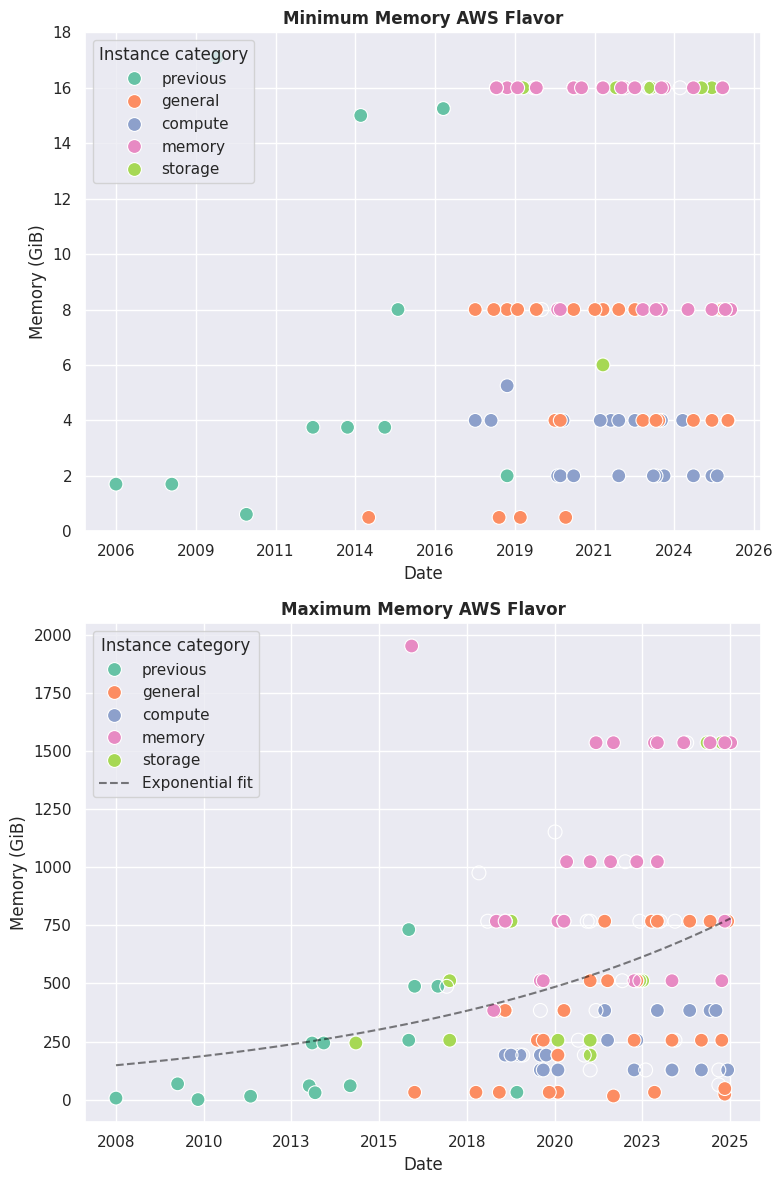

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from scipy.optimize import curve_fit

fig, axes = plt.subplots(2, 1, figsize=(8, 12))

# --- MIN memory (left) ---
flavor_min_small_mem = flavor_min.loc[flavor_min['Memory (GiB)'] <= 18]
x_years_min_mem = (flavor_min_small_mem['date'] - flavor_min_small_mem['date'].min()).dt.days / 365
y_min_mem = flavor_min_small_mem['Memory (GiB)']

sns.scatterplot(
    data=flavor_min_small_mem,
    x=x_years_min_mem,
    y=y_min_mem,
    hue='category',
    hue_order=['previous', 'general', 'compute', 'memory', 'storage'],
    palette='Set2',
    s=100,
    ax=axes[0]
)
axes[0].set_xlabel("Date")
axes[0].set_ylabel("Memory (GiB)")
axes[0].set_title("Minimum Memory AWS Flavor", fontsize=12, fontweight='bold')
axes[0].set_ylim(0, 18)
axes[0].legend(title="Instance category", loc='upper left')

# linear fit with fixed intercept at 2
def linear_fixed_intercept(x, slope):
    return 2 + slope * x

popt, _ = curve_fit(linear_fixed_intercept, x_years_min_mem, y_min_mem, p0=[1])
slope = popt[0]
x_fit = np.linspace(0, x_years_min_mem.max(), 200)
y_fit = linear_fixed_intercept(x_fit, slope)
# axes[0].plot(x_fit, y_fit, 'k--', alpha=0.7, label='Linear fit')
# axes[0].legend(loc='upper left')

# manage x-axis ticks using ordinal conversion
flavor_min_small_mem['date_num'] = flavor_min_small_mem['date'].map(pd.Timestamp.toordinal)
xticks = axes[0].get_xticks()
dates = [pd.Timestamp.fromordinal(int(flavor_min_small_mem['date_num'].min() + t*365)).strftime('%Y') for t in xticks]
axes[0].set_xticklabels(dates)

# --- MAX memory (right) ---
# compute ordinal dates for consistency
flavor_max['date_num'] = flavor_max['date'].map(pd.Timestamp.toordinal)
x_scaled_max = (flavor_max['date_num'] - flavor_max['date_num'].min()) / 365
y_max_mem = flavor_max['Memory (GiB)']

sns.scatterplot(
    data=flavor_max,
    x=x_scaled_max,
    y=y_max_mem,
    hue='category',
    hue_order=['previous', 'general', 'compute', 'memory', 'storage'],
    palette='Set2',
    s=100,
    ax=axes[1]
)
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Memory (GiB)")
axes[1].set_title("Maximum Memory AWS Flavor", fontsize=12, fontweight='bold')


# exponential fit
def exp_func(x, A, B):
    return A * np.exp(B * x)

popt, _ = curve_fit(exp_func, x_scaled_max, y_max_mem, p0=(1, 2))
x_vals = np.linspace(x_scaled_max.min(), x_scaled_max.max(), 200)
y_vals = exp_func(x_vals, *popt)
axes[1].plot(x_vals, y_vals, color='black', alpha=0.5, linestyle='--', label='Exponential fit')
axes[1].legend()
axes[1].legend(title="Instance category", loc='upper left')
#axes[1].set(ylim=(256,512))

# manage x-axis ticks using ordinal conversion
xticks = axes[1].get_xticks()
dates = [pd.Timestamp.fromordinal(int(flavor_max['date_num'].min() + t*365)).strftime('%Y') for t in xticks]
axes[1].set_xticklabels(dates)

plt.tight_layout()
plt.gcf().savefig('figures/flavors-aws-mem.pdf', bbox_inches='tight')
plt.show()

# Explo

In [35]:
merged_df['GiB_per_vCPU'] = merged_df['Memory (GiB)'] / merged_df['vCPUs']

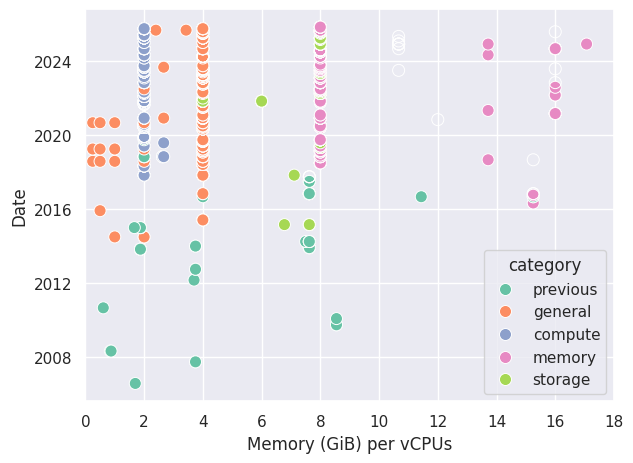

In [36]:
sns.scatterplot(
    data=merged_df,
    x='GiB_per_vCPU',
    y='date',
    hue='category',
    s=75,
    palette='Set2',
    hue_order=['previous', 'general', 'compute', 'memory', 'storage'],
)

plt.tight_layout()
plt.xlabel("Memory (GiB) per vCPUs")
plt.ylabel("Date")
plt.xlim(0,18)
plt.gcf().savefig('figures/flavors-aws-ratio.pdf', bbox_inches='tight')
plt.show()

In [37]:
merged_df

,_index,uid,instance_type,instance_category,instance_generation,release_month,release_year,product_page,announcement_url,date,...,Processor,vCPUs,CPU cores,Threads per core,Accelerator count,Accelerators,Accelerator memory,category,product_id,GiB_per_vCPU
0,1,451c1cd49a2f955d,m1.small,General Purpose,Previous generation,August,2006,https://aws.amazon.com/ec2/previous-generation/,https://aws.amazon.com/about-aws/whats-new/200...,2006-08-01,...,Intel Xeon Family,1,1,1,NaN,NaN,NaN,previous,m1,1.700000
1,2,85589f23e811f229,m1.large,General Purpose,Previous generation,October,2007,https://aws.amazon.com/ec2/previous-generation/,https://aws.amazon.com/about-aws/whats-new/200...,2007-10-01,...,Intel Xeon Family,2,2,1,NaN,NaN,NaN,previous,m1,3.750000
2,3,db881dc65b70a128,m1.xlarge,General Purpose,Previous generation,October,2007,https://aws.amazon.com/ec2/previous-generation/,https://aws.amazon.com/about-aws/whats-new/200...,2007-10-01,...,Intel Xeon Family,4,4,1,NaN,NaN,NaN,previous,m1,3.750000
3,4,719785bb62b69257,c1.medium,Compute Optimized,Previous generation,May,2008,https://aws.amazon.com/ec2/previous-generation/,None,2008-05-01,...,Intel Xeon Family,2,2,1,NaN,NaN,NaN,previous,c1,0.850000
4,5,14861a4162144a39,c1.xlarge,Compute Optimized,Previous generation,May,2008,https://aws.amazon.com/ec2/previous-generation/,None,2008-05-01,...,Intel Xeon Family,8,8,1,NaN,NaN,NaN,previous,c1,0.875000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1059,1069,8816091f9048ec64,r8a.12xlarge,Memory Optimized,Current generation,November,2025,https://aws.amazon.com/ec2/instance-types/r8a/,https://aws.amazon.com/about-aws/whats-new/202...,2025-11-01,...,AMD EPYC 9R45,48,48,1,NaN,NaN,NaN,memory,r8a,8.000000
1060,1070,1ef227a41df5f9e9,r8a.16xlarge,Memory Optimized,Current generation,November,2025,https://aws.amazon.com/ec2/instance-types/r8a/,https://aws.amazon.com/about-aws/whats-new/202...,2025-11-01,...,AMD EPYC 9R45,64,64,1,NaN,NaN,NaN,memory,r8a,8.000000
1061,1071,86a1776263254f33,r8a.24xlarge,Memory Optimized,Current generation,November,2025,https://aws.amazon.com/ec2/instance-types/r8a/,https://aws.amazon.com/about-aws/whats-new/202...,2025-11-01,...,AMD EPYC 9R45,96,96,1,NaN,NaN,NaN,memory,r8a,8.000000
1062,1072,3f9771ca1352dc0a,r8a.48xlarge,Memory Optimized,Current generation,November,2025,https://aws.amazon.com/ec2/instance-types/r8a/,https://aws.amazon.com/about-aws/whats-new/202...,2025-11-01,...,AMD EPYC 9R45,192,192,1,NaN,NaN,NaN,memory,r8a,8.000000


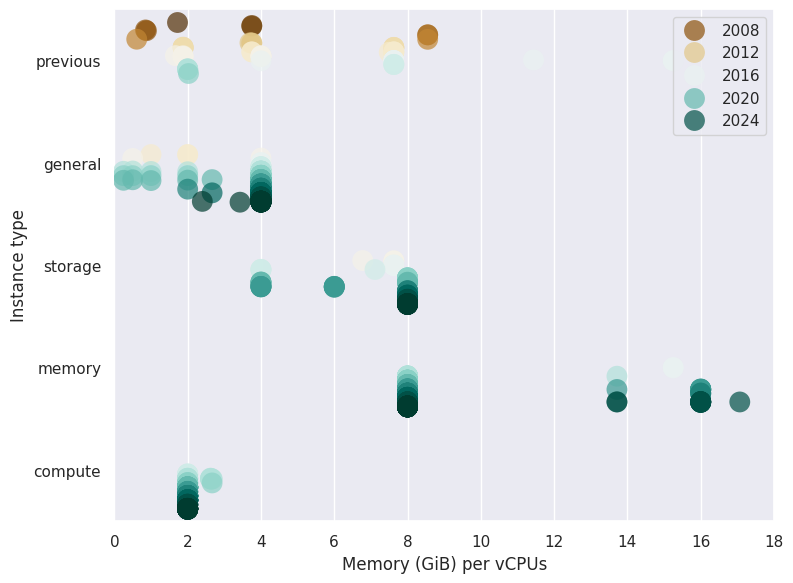

In [38]:
plt.figure(figsize=(8, 6))

sns.stripplot(
    data=merged_df[merged_df['category'].isin(['previous', 'general', 'compute', 'memory', 'storage'])],
    x='GiB_per_vCPU',
    y='category',
    hue='release_year',
    s=15,
    palette='BrBG',
    dodge=True,
    alpha=0.7
)
plt.tight_layout()
plt.xlabel("Memory (GiB) per vCPUs")
plt.ylabel("Instance type")
plt.xlim(0,18)
plt.legend(loc='upper right')
plt.gcf().savefig('figures/flavors-aws-ratio.pdf', bbox_inches='tight')